In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

In [3]:
matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [4]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [5]:
print('Matches:', matches.shape)
print('Deliveries:', deliveries.shape)

Matches: (756, 18)
Deliveries: (179078, 21)


In [6]:
print('Matches Columns')
print(matches.columns)

print('\nDeliveries Columns')
print(deliveries.columns)

Matches Columns
Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')

Deliveries Columns
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


In [7]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               756 non-null    int64
 1   season           756 non-null    int64
 2   city             749 non-null    str  
 3   date             756 non-null    str  
 4   team1            756 non-null    str  
 5   team2            756 non-null    str  
 6   toss_winner      756 non-null    str  
 7   toss_decision    756 non-null    str  
 8   result           756 non-null    str  
 9   dl_applied       756 non-null    int64
 10  winner           752 non-null    str  
 11  win_by_runs      756 non-null    int64
 12  win_by_wickets   756 non-null    int64
 13  player_of_match  752 non-null    str  
 14  venue            756 non-null    str  
 15  umpire1          754 non-null    str  
 16  umpire2          754 non-null    str  
 17  umpire3          119 non-null    str  
dtypes: int64(5), str(13)


In [8]:
deliveries.info()

<class 'pandas.DataFrame'>
RangeIndex: 179078 entries, 0 to 179077
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          179078 non-null  int64
 1   inning            179078 non-null  int64
 2   batting_team      179078 non-null  str  
 3   bowling_team      179078 non-null  str  
 4   over              179078 non-null  int64
 5   ball              179078 non-null  int64
 6   batsman           179078 non-null  str  
 7   non_striker       179078 non-null  str  
 8   bowler            179078 non-null  str  
 9   is_super_over     179078 non-null  int64
 10  wide_runs         179078 non-null  int64
 11  bye_runs          179078 non-null  int64
 12  legbye_runs       179078 non-null  int64
 13  noball_runs       179078 non-null  int64
 14  penalty_runs      179078 non-null  int64
 15  batsman_runs      179078 non-null  int64
 16  extra_runs        179078 non-null  int64
 17  total_runs        179

In [9]:
print('Match Missing Values:')
print('\n', matches.isnull().sum())

Match Missing Values:

 id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64


In [10]:
missing_percent = matches.isnull().sum() / len(matches) * 100

missing_percent[missing_percent > 0].sort_values(ascending = False)

umpire3            84.259259
city                0.925926
winner              0.529101
player_of_match     0.529101
umpire1             0.264550
umpire2             0.264550
dtype: float64

In [11]:
matches[matches['winner'].isnull()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
300,301,2011,Delhi,2011-05-21,Delhi Daredevils,Pune Warriors,Delhi Daredevils,bat,no result,0,NaN,0,0,NaN,Feroz Shah Kotla,SS Hazare,RJ Tucker,NaN
545,546,2015,Bangalore,2015-04-29,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,JD Cloete,PG Pathak,NaN
570,571,2015,Bangalore,2015-05-17,Delhi Daredevils,Royal Challengers Bangalore,Royal Challengers Bangalore,field,no result,0,NaN,0,0,NaN,M Chinnaswamy Stadium,HDPK Dharmasena,K Srinivasan,NaN
744,11340,2019,Bengaluru,30/04/19,Royal Challengers Bangalore,Rajasthan Royals,Rajasthan Royals,field,no result,0,NaN,0,0,NaN,M. Chinnaswamy Stadium,Nigel Llong,Ulhas Gandhe,Anil Chaudhary


In [12]:
matches['result'].value_counts(dropna = False)

result
normal       743
tie            9
no result      4
Name: count, dtype: int64

In [13]:
matches[matches['city'].isnull()]

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
461,462,2014,NaN,2014-04-19,Mumbai Indians,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Royal Challengers Bangalore,0,7,PA Patel,Dubai International Cricket Stadium,Aleem Dar,AK Chaudhary,NaN
462,463,2014,NaN,2014-04-19,Kolkata Knight Riders,Delhi Daredevils,Kolkata Knight Riders,bat,normal,0,Delhi Daredevils,0,4,JP Duminy,Dubai International Cricket Stadium,Aleem Dar,VA Kulkarni,NaN
466,467,2014,NaN,2014-04-23,Chennai Super Kings,Rajasthan Royals,Rajasthan Royals,field,normal,0,Chennai Super Kings,7,0,RA Jadeja,Dubai International Cricket Stadium,HDPK Dharmasena,RK Illingworth,NaN
468,469,2014,NaN,2014-04-25,Sunrisers Hyderabad,Delhi Daredevils,Sunrisers Hyderabad,bat,normal,0,Sunrisers Hyderabad,4,0,AJ Finch,Dubai International Cricket Stadium,M Erasmus,S Ravi,NaN
469,470,2014,NaN,2014-04-25,Mumbai Indians,Chennai Super Kings,Mumbai Indians,bat,normal,0,Chennai Super Kings,0,7,MM Sharma,Dubai International Cricket Stadium,BF Bowden,M Erasmus,NaN
474,475,2014,NaN,2014-04-28,Royal Challengers Bangalore,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,5,Sandeep Sharma,Dubai International Cricket Stadium,BF Bowden,S Ravi,NaN
476,477,2014,NaN,2014-04-30,Sunrisers Hyderabad,Mumbai Indians,Mumbai Indians,field,normal,0,Sunrisers Hyderabad,15,0,B Kumar,Dubai International Cricket Stadium,HDPK Dharmasena,M Erasmus,NaN


In [14]:
matches.duplicated().sum()

np.int64(0)

In [15]:
deliveries.duplicated().sum()

np.int64(23)

In [16]:
deliveries[deliveries.duplicated(keep = False)].sort_values( by = ['match_id', 'inning', 'over', 'ball'])

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
52169,221,1,Mumbai Indians,Delhi Daredevils,4,1,SR Tendulkar,C Madan,PJ Sangwan,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
52178,221,1,Mumbai Indians,Delhi Daredevils,4,1,SR Tendulkar,C Madan,PJ Sangwan,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
162803,7946,1,Rajasthan Royals,Royal Challengers Bangalore,4,4,AM Rahane,RA Tripathi,UT Yadav,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
162805,7946,1,Rajasthan Royals,Royal Challengers Bangalore,4,4,AM Rahane,RA Tripathi,UT Yadav,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
162804,7946,1,Rajasthan Royals,Royal Challengers Bangalore,4,5,AM Rahane,RA Tripathi,UT Yadav,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
162806,7946,1,Rajasthan Royals,Royal Challengers Bangalore,4,5,AM Rahane,RA Tripathi,UT Yadav,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
162863,7946,1,Rajasthan Royals,Royal Challengers Bangalore,13,5,RA Tripathi,AM Rahane,YS Chahal,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
162870,7946,1,Rajasthan Royals,Royal Challengers Bangalore,13,5,RA Tripathi,AM Rahane,YS Chahal,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
162963,7946,2,Royal Challengers Bangalore,Rajasthan Royals,10,1,AB de Villiers,Mandeep Singh,I Sodhi,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
162964,7946,2,Royal Challengers Bangalore,Rajasthan Royals,10,1,AB de Villiers,Mandeep Singh,I Sodhi,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN


In [17]:
deliveries = deliveries.drop_duplicates().reset_index(drop = True)

In [18]:
print('Duplicate Rows: ', deliveries.duplicated().sum())
print('New Shape:', deliveries.shape)

Duplicate Rows:  0
New Shape: (179055, 21)


In [19]:
matches['date'] = pd.to_datetime(matches['date'], format = 'mixed', dayfirst = True)


In [20]:
matches['date'].dtype

dtype('<M8[us]')

In [21]:
matches[['date', 'season']].head(10)

,date,season
0,2017-05-04,2017
1,2017-06-04,2017
2,2017-07-04,2017
3,2017-08-04,2017
4,2017-08-04,2017
5,2017-09-04,2017
6,2017-09-04,2017
7,2017-10-04,2017
8,2017-11-04,2017
9,2017-12-04,2017


In [22]:
matches['date'].isnull().sum()

np.int64(0)

In [23]:
print('Deliveries Missing Values:')
print('\n', deliveries.isnull().sum())

Deliveries Missing Values:

 match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    170221
dismissal_kind      170221
fielder             172607
dtype: int64


In [24]:
print('Seasons:')
sorted(matches['season'].unique())

Seasons:


[np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018),
 np.int64(2019)]

In [25]:
teams = pd.unique(matches[['team1', 'team2']].values.ravel())

print('Total teams:', len(teams))
print('\nTeams:')
print(sorted(teams))

Total teams: 15

Teams:
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


In [26]:
sorted(matches['winner'].dropna().unique())

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Mumbai Indians',
 'Pune Warriors',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Sunrisers Hyderabad']

In [27]:
result_percentage = matches['result'].value_counts(normalize = True).mul(100).round(2)

result_percentage

result
normal       98.28
tie           1.19
no result     0.53
Name: proportion, dtype: float64

In [28]:
matches['win_by_runs'].describe()

count    756.000000
mean      13.283069
std       23.471144
min        0.000000
25%        0.000000
50%        0.000000
75%       19.000000
max      146.000000
Name: win_by_runs, dtype: float64

In [29]:
matches['win_by_wickets'].describe()

count    756.000000
mean       3.350529
std        3.387963
min        0.000000
25%        0.000000
50%        4.000000
75%        6.000000
max       10.000000
Name: win_by_wickets, dtype: float64

In [30]:
print(matches[
    (matches['win_by_runs'] > 0)
    &  (matches['win_by_wickets'] > 0)
    ][['winner', 'win_by_runs', 'win_by_wickets']]
)  

Empty DataFrame
Columns: [winner, win_by_runs, win_by_wickets]
Index: []


In [31]:
deliveries[['over', 'ball', 'batsman_runs', 'extra_runs', 'total_runs']].describe()

,over,ball,batsman_runs,extra_runs,total_runs
count,179055.000000,179055.000000,179055.000000,179055.000000,179055.000000
mean,10.162916,3.615543,1.246913,0.067035,1.313948
std,5.677628,1.806869,1.608322,0.342567,1.605470
min,1.000000,1.000000,0.000000,0.000000,0.000000
25%,5.000000,2.000000,0.000000,0.000000,0.000000
50%,10.000000,4.000000,1.000000,0.000000,1.000000
75%,15.000000,5.000000,1.000000,0.000000,1.000000
max,20.000000,9.000000,7.000000,7.000000,10.000000


In [32]:
deliveries['inning'].value_counts().sort_index()

inning
1    92727
2    86232
3       50
4       38
5        8
Name: count, dtype: int64

# starting EDA

In [33]:
# Winning Count
team_wins = matches['winner'].value_counts()
team_wins

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

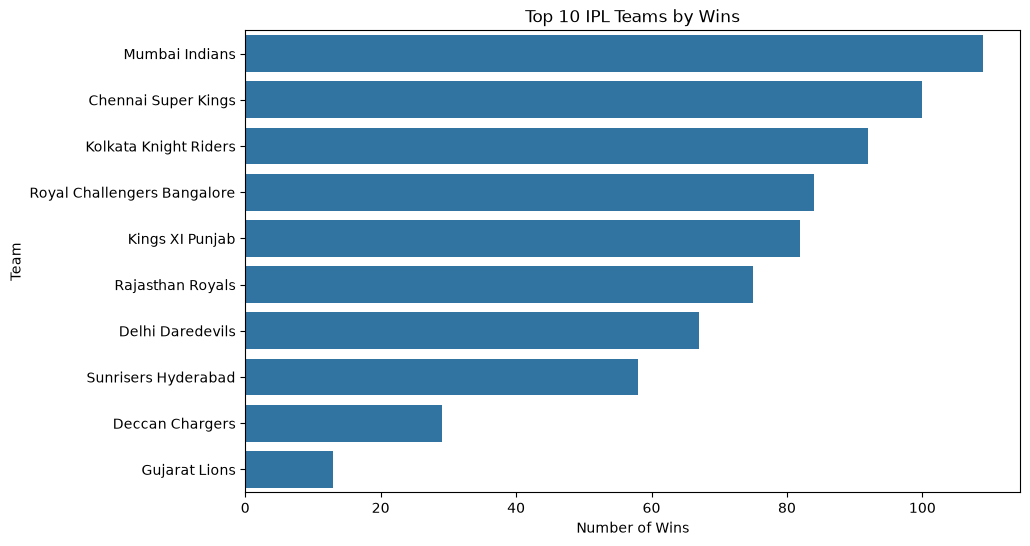

In [34]:
plt.figure(figsize = (10, 6))

sns.barplot(x = team_wins.head(10).values, y = team_wins.head(10).index)

plt.title('Top 10 IPL Teams by Wins')
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.show()

In [35]:
matches['winner'].value_counts()

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Kings XI Punjab                 82
Rajasthan Royals                75
Delhi Daredevils                67
Sunrisers Hyderabad             58
Deccan Chargers                 29
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Delhi Capitals                  10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64

In [36]:
team1_count = matches['team1'].value_counts()
team2_count = matches['team2'].value_counts()

matches_played = team1_count.add(team2_count, fill_value = 0)
matches_played = matches_played.sort_values(ascending = False)

matches_played

team1
Mumbai Indians                 187
Royal Challengers Bangalore    180
Kolkata Knight Riders          178
Kings XI Punjab                176
Chennai Super Kings            164
Delhi Daredevils               161
Rajasthan Royals               147
Sunrisers Hyderabad            108
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Lions                   30
Rising Pune Supergiant          16
Delhi Capitals                  16
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

In [37]:
team_stats = pd.DataFrame({
    'matches_played': matches_played,
    'wins': team_wins
})

team_stats = team_stats.sort_values(ascending = False, by = 'matches_played')
team_stats

,matches_played,wins
Mumbai Indians,187,109
Royal Challengers Bangalore,180,84
Kolkata Knight Riders,178,92
Kings XI Punjab,176,82
Chennai Super Kings,164,100
Delhi Daredevils,161,67
Rajasthan Royals,147,75
Sunrisers Hyderabad,108,58
Deccan Chargers,75,29
Pune Warriors,46,12


In [38]:
team_stats['win_percentage'] = (team_stats['wins'] /
                               team_stats['matches_played']) * 100

team_stats['win_percentage'] = team_stats['win_percentage'].round(2)

team_stats

,matches_played,wins,win_percentage
Mumbai Indians,187,109,58.29
Royal Challengers Bangalore,180,84,46.67
Kolkata Knight Riders,178,92,51.69
Kings XI Punjab,176,82,46.59
Chennai Super Kings,164,100,60.98
Delhi Daredevils,161,67,41.61
Rajasthan Royals,147,75,51.02
Sunrisers Hyderabad,108,58,53.70
Deccan Chargers,75,29,38.67
Pune Warriors,46,12,26.09


In [39]:
reliable_teams = team_stats[team_stats['matches_played'] > 50].sort_values(by = 'win_percentage', ascending = False)

reliable_teams

,matches_played,wins,win_percentage
Chennai Super Kings,164,100,60.98
Mumbai Indians,187,109,58.29
Sunrisers Hyderabad,108,58,53.70
Kolkata Knight Riders,178,92,51.69
Rajasthan Royals,147,75,51.02
Royal Challengers Bangalore,180,84,46.67
Kings XI Punjab,176,82,46.59
Delhi Daredevils,161,67,41.61
Deccan Chargers,75,29,38.67


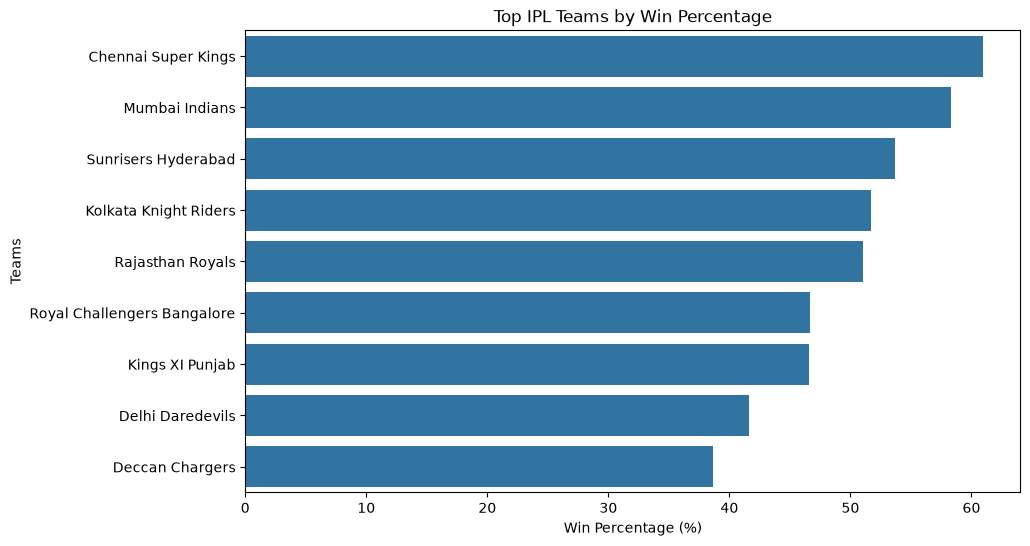

In [40]:
top_win_percentage = reliable_teams.head(10)

plt.figure(figsize = (10, 6) )

sns.barplot(x = top_win_percentage['win_percentage'], y = top_win_percentage.index)

plt.title('Top IPL Teams by Win Percentage')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Teams')
plt.show()

##  Team Performance Analysis

###  Total Wins by Team
###  Matches Played by Team
###  Win Percentage by Team

In [41]:
team_name_mapping = {
    'Rising Pune Supergiants' : 'Rising Pune Supergiant',
    'Delhi Daredevils' : 'Delhi Capitals',
    'Kings XI Punjab' : 'Punjab Kings'
}

matches['team1'] = matches['team1'].replace(team_name_mapping)
matches['team2'] = matches['team2'].replace(team_name_mapping)
matches['toss_winner'] = matches['toss_winner'].replace(team_name_mapping)
matches['winner'] = matches['winner'].replace(team_name_mapping)

deliveries['batting_team'] = deliveries['batting_team'].replace(team_name_mapping)
deliveries['bowling_team'] = deliveries['bowling_team'].replace(team_name_mapping)

In [42]:
teams = pd.unique(matches[['team1', 'team2']].values.ravel())

print('Total teams:', len(teams))
print(sorted(teams))

Total teams: 13
['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Gujarat Lions', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Royal Challengers Bangalore', 'Sunrisers Hyderabad']


----TOP TEAMS BY TOTAL WINS----

                        matches_played  wins  win_percentage
Chennai Super Kings               164   100            61.0
Deccan Chargers                    75    29            39.0
Delhi Capitals                    177    77            44.0
Gujarat Lions                      30    13            43.0
Kochi Tuskers Kerala               14     6            43.0
Kolkata Knight Riders             178    92            52.0
Mumbai Indians                    187   109            58.0
Pune Warriors                      46    12            26.0
Punjab Kings                      176    82            47.0
Rajasthan Royals                  147    75            51.0

-- TOP TEAMS BY WIN PERCENTAGE --

                              matches_played  wins  win_percentage
Chennai Super Kings                     164   100            61.0
Mumbai Indians                          187   109            58.0
Sunrisers Hyderabad                     108    58            54.0
Kolka

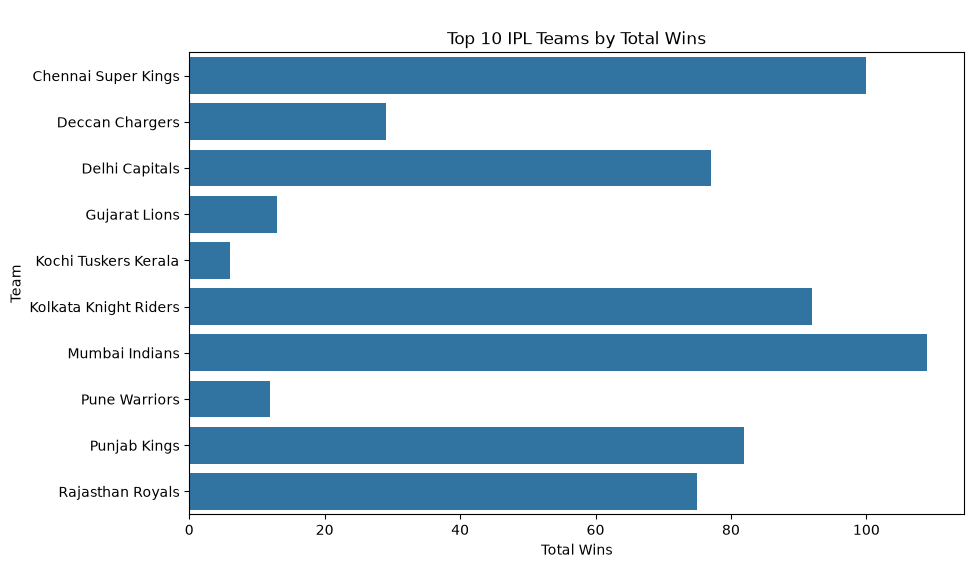

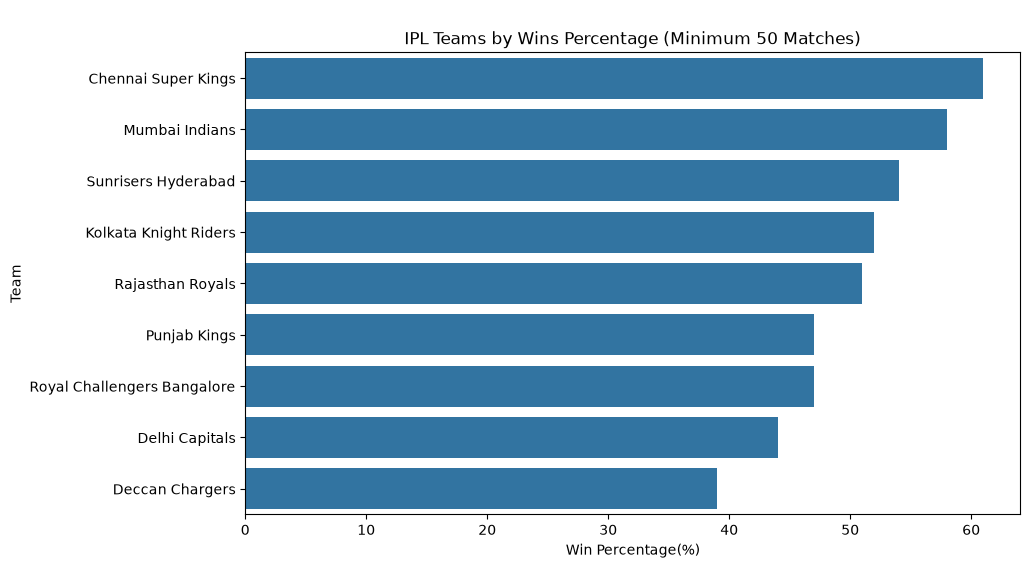

In [43]:
team1_count = matches['team1'].value_counts()
team2_count = matches['team2'].value_counts()

matches_played = team1_count.add(team2_count, fill_value = 0)

team_wins = matches['winner'].value_counts()

team_stats = pd.DataFrame({
    'matches_played' : matches_played,
    'wins' : team_wins
})

team_stats['win_percentage'] = (
    team_stats['wins'] / team_stats['matches_played']
) * 100

team_stats['win_percentage'] = team_stats['win_percentage'].round()

team_stats.sort_values('win_percentage', ascending = False)

reliable_teams = team_stats[team_stats['matches_played'] >= 50].sort_values('win_percentage', ascending = False)

print('----TOP TEAMS BY TOTAL WINS----')
print('\n',team_stats.head(10))

print('\n-- TOP TEAMS BY WIN PERCENTAGE --')
print('\n', reliable_teams)

# Visualization - Total Wins
plt.figure(figsize = (10, 6))
sns.barplot(x = team_stats.head(10)['wins'], y = team_stats.head(10).index)

plt.title('\nTop 10 IPL Teams by Total Wins')
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.show()


# Visualization = Win Percentage
plt.figure(figsize = (10, 6))
sns.barplot(x = reliable_teams.head(10)['win_percentage'], y = reliable_teams.index)

plt.title('\nIPL Teams by Wins Percentage (Minimum 50 Matches)')
plt.xlabel('Win Percentage(%)')
plt.ylabel('Team')
plt.show()



-- TOSS DECISION --
toss_decision
field    463
bat      293
Name: count, dtype: int64

 -- TOSS WINNER VS MATCH WINNER --
toss_match_winner
True     393
False    359
Name: count, dtype: int64

Toss winner also won the match:52.26%

 -- TOSS DECISION VS MATCH RESULT -- 
toss_match_winner  False  True 
toss_decision                  
bat                  159    134
field                204    259


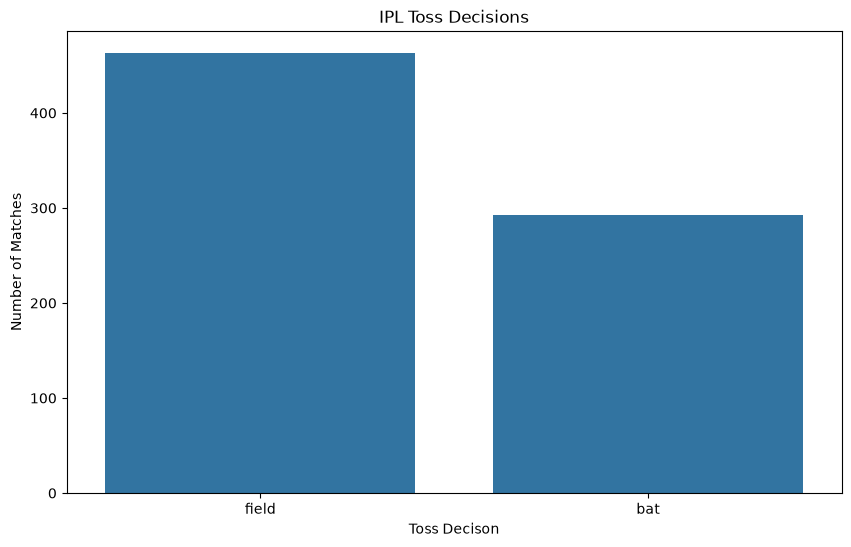

In [44]:
# Toss Analysis
toss_decision = matches['toss_decision'].value_counts()

print('\n-- TOSS DECISION --')
print(toss_decision)

matches['toss_match_winner'] = (matches['toss_winner'] == matches['winner'])

toss_result = matches[matches['winner'].notna()]['toss_match_winner'].value_counts()

print('\n -- TOSS WINNER VS MATCH WINNER --')
print(toss_result)

toss_win_percentage = (matches[matches['winner'].notna()]['toss_match_winner'].mean() * 100)

print(f'\nToss winner also won the match:'f'{toss_win_percentage:.2f}%')

# Toss decision vs match result
toss_decision_result = pd.crosstab(matches['toss_decision'], matches['toss_match_winner'])

print('\n -- TOSS DECISION VS MATCH RESULT -- ')
print(toss_decision_result)

# Visualization
plt.figure(figsize = (10, 6))
sns.countplot(data = matches, x = 'toss_decision')
plt.title('IPL Toss Decisions')
plt.xlabel('Toss Decison')
plt.ylabel('Number of Matches')
plt.show()




Top 15 Venues by Matches:

 venue
Eden Gardens                                            77
M Chinnaswamy Stadium                                   73
Wankhede Stadium                                        73
Feroz Shah Kotla                                        67
Rajiv Gandhi International Stadium, Uppal               56
MA Chidambaram Stadium, Chepauk                         49
Sawai Mansingh Stadium                                  47
Punjab Cricket Association Stadium, Mohali              35
Maharashtra Cricket Association Stadium                 21
Dr DY Patil Sports Academy                              17
Subrata Roy Sahara Stadium                              17
Kingsmead                                               15
Punjab Cricket Association IS Bindra Stadium, Mohali    14
SuperSport Park                                         12
Sardar Patel Stadium, Motera                            12
Name: count, dtype: int64


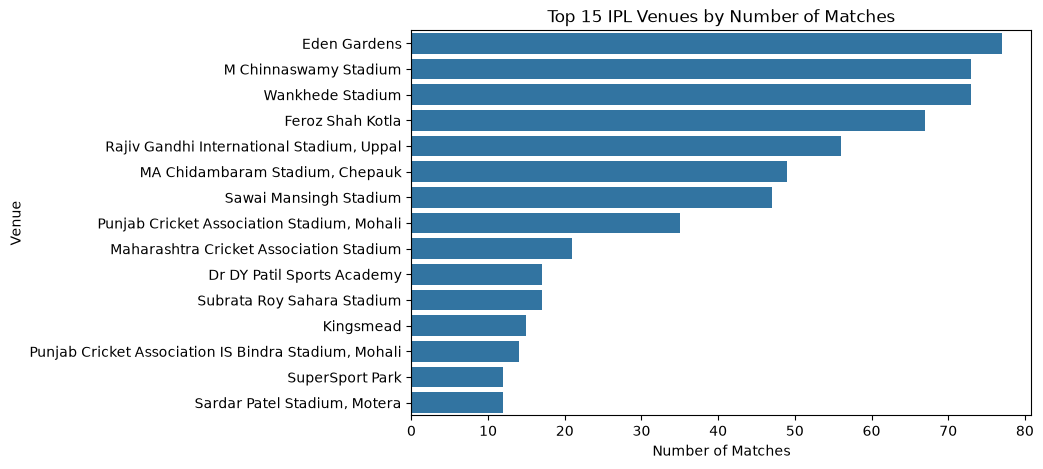

In [45]:
venue_matches = matches['venue'].value_counts()

print('Top 15 Venues by Matches:')
print('\n', venue_matches.head(15))


plt.figure(figsize = (8, 5))
sns.barplot( x = venue_matches.head(15).values, y = venue_matches.head(15).index)
plt.title('Top 15 IPL Venues by Number of Matches')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.show()

In [46]:
venue_runs = deliveries.groupby('match_id')['total_runs'].sum()

matches['total_match_runs'] = matches['id'].map(venue_runs)

venue_scoring = (
    matches.groupby('venue').agg(
        matches = ('id', 'count'),
        total_runs = ('total_match_runs', 'sum'),
        avg_runs = ('total_match_runs', 'mean')).sort_values('avg_runs', ascending = False))
venue_scoring.head(15)

,matches,total_runs,avg_runs
venue,,,
IS Bindra Stadium,7,2482,354.571429
Brabourne Stadium,11,3841,349.181818
M. Chinnaswamy Stadium,7,2342,334.571429
"Punjab Cricket Association IS Bindra Stadium, Mohali",14,4681,334.357143
Saurashtra Cricket Association Stadium,10,3333,333.300000
ACA-VDCA Stadium,2,658,329.000000
Maharashtra Cricket Association Stadium,21,6871,327.190476
Rajiv Gandhi Intl. Cricket Stadium,8,2617,327.125000
Barabati Stadium,7,2278,325.428571


In [47]:
reliable_venues = venue_scoring[venue_scoring['matches'] >= 10].sort_values(
    'avg_runs', ascending = False)
reliable_venues.head(15)


,matches,total_runs,avg_runs
venue,,,
Brabourne Stadium,11,3841,349.181818
"Punjab Cricket Association IS Bindra Stadium, Mohali",14,4681,334.357143
Saurashtra Cricket Association Stadium,10,3333,333.300000
Maharashtra Cricket Association Stadium,21,6871,327.190476
Wankhede Stadium,73,23648,323.945205
"MA Chidambaram Stadium, Chepauk",49,15696,320.326531
M Chinnaswamy Stadium,73,23267,318.726027
"Sardar Patel Stadium, Motera",12,3767,313.916667
"Punjab Cricket Association Stadium, Mohali",35,10987,313.914286


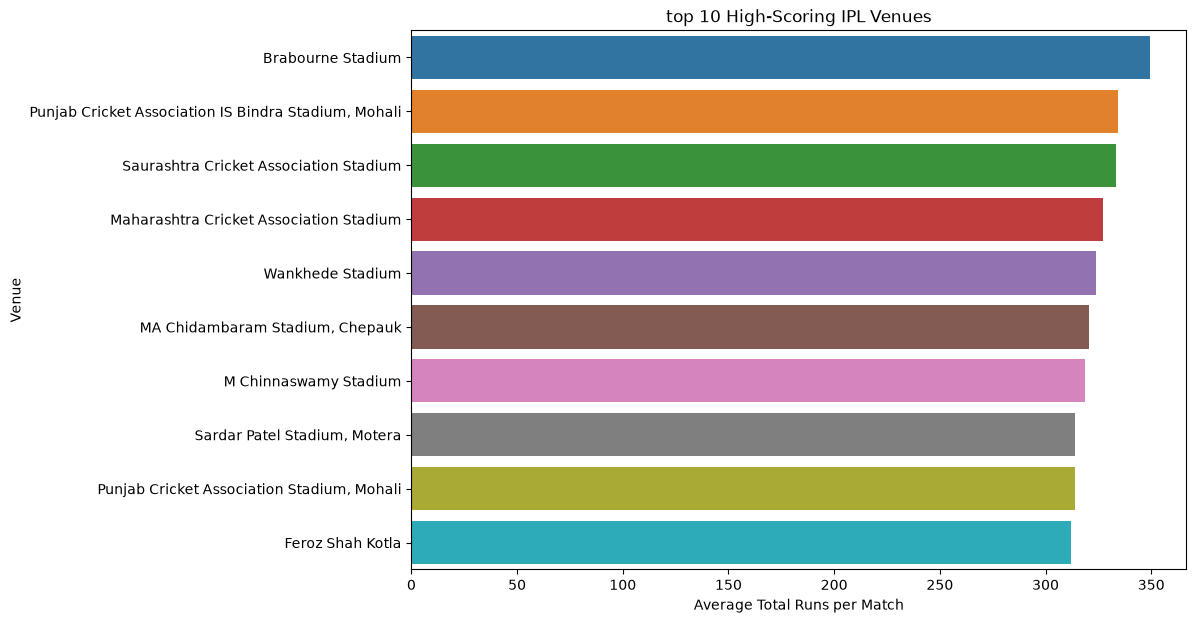

In [48]:
# High Scoring venues
plt.figure(figsize = (10, 7))
sns.barplot(data = reliable_venues.head(10), x = 'avg_runs', y = reliable_venues.head(10).index, hue = 'venue')
plt.title('top 10 High-Scoring IPL Venues')
plt.xlabel('Average Total Runs per Match')
plt.ylabel('Venue')
plt.show()

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4631
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4444
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64


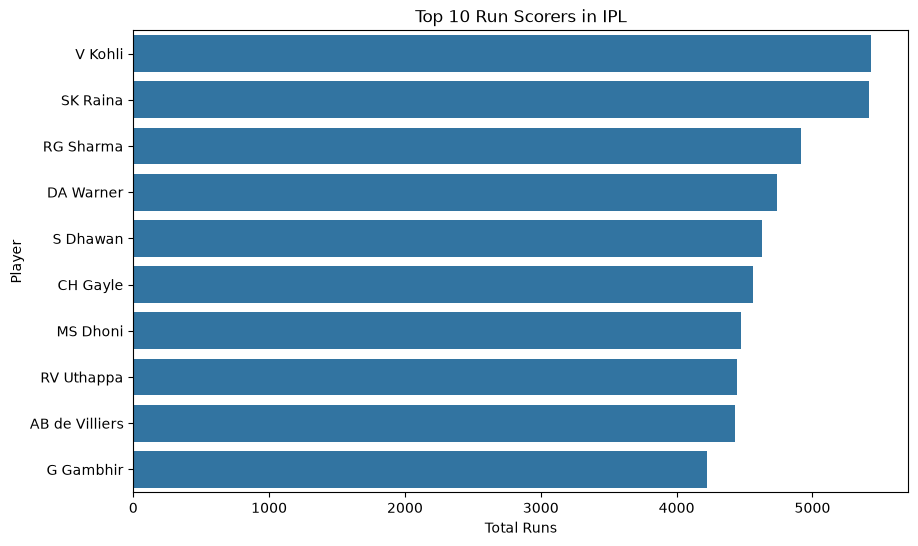

In [49]:
player_runs = (deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending = False))
print(player_runs.head(10))

# Visualization
plt.figure(figsize = (10, 6))
sns.barplot(x = player_runs.head(10).values, y = player_runs.head(10).index)

plt.title('Top 10 Run Scorers in IPL')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.show()

In [50]:
# Most Boundaries

fours = (deliveries[deliveries['batsman_runs'] == 4].groupby('batsman').size().sort_values(ascending = False))

print('Top 10 Four Hitters:')
print(fours.head(10))

Top 10 Four Hitters:
batsman
S Dhawan      526
SK Raina      495
G Gambhir     492
V Kohli       482
DA Warner     459
RV Uthappa    436
RG Sharma     431
AM Rahane     404
CH Gayle      376
PA Patel      366
dtype: int64


In [51]:
sixes = (deliveries[deliveries['batsman_runs'] == 6].groupby('batsman').size().sort_values(ascending = False))

print('\n Top 10 Six Hitters:')
sixes.head(10)


 Top 10 Six Hitters:


batsman
CH Gayle          327
AB de Villiers    214
MS Dhoni          207
SK Raina          195
RG Sharma         194
V Kohli           191
DA Warner         181
SR Watson         177
KA Pollard        175
YK Pathan         161
dtype: int64

In [52]:
# top wicket takers

bowler_wickets = deliveries[deliveries['dismissal_kind'].notna() & ~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]

wickets = (bowler_wickets.groupby('bowler').size().sort_values(ascending = False))

print('Top 10 Wicket Takers:')
wickets.head(10)

Top 10 Wicket Takers:


bowler
SL Malinga         170
A Mishra           156
Harbhajan Singh    150
PP Chawla          149
DJ Bravo           147
B Kumar            133
R Ashwin           125
SP Narine          122
UT Yadav           119
RA Jadeja          108
dtype: int64

season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
2018    60
2019    60
Name: count, dtype: int64


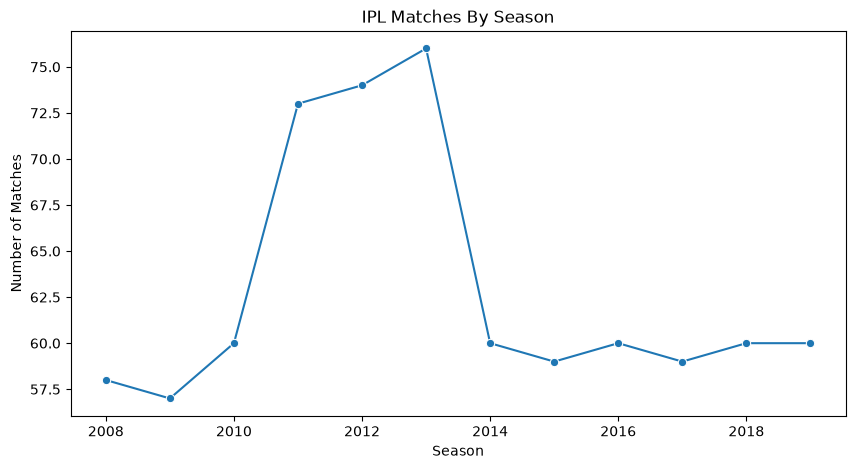

In [53]:
# Season-wise Analysis

season_matches = matches['season'].value_counts().sort_index()
print(season_matches)


# visualization
plt.figure(figsize = (10, 5))
sns.lineplot(x = season_matches.index, y = season_matches.values, marker = 'o')

plt.title('IPL Matches By Season')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.show()

season
2008    309.258621
2009    286.894737
2010    314.700000
2011    289.780822
2012    303.418919
2013    297.394737
2014    315.516667
2015    311.067797
2016    314.366667
2017    318.406780
2018    345.016667
2019    337.583333
Name: total_match_runs, dtype: float64


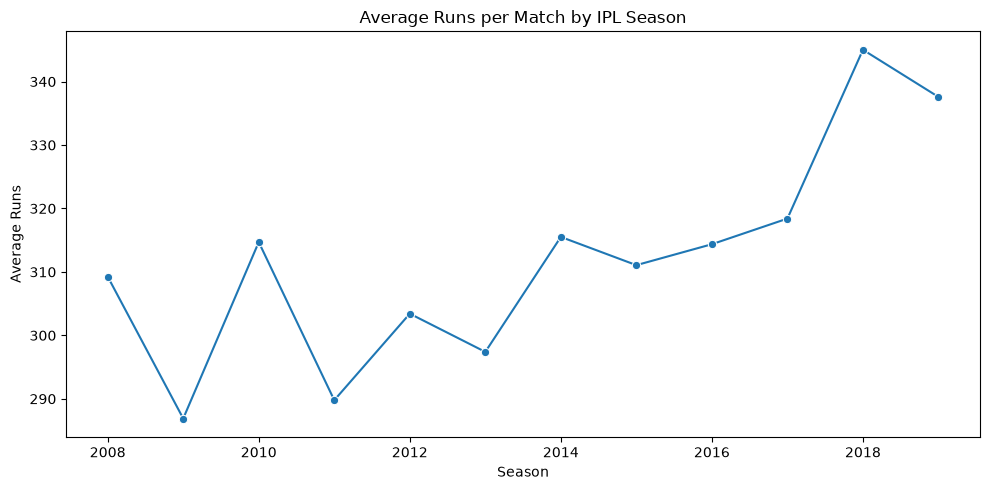

In [54]:
# Average runs per match by season

season_runs = (matches.groupby('season')['total_match_runs'].mean())
print(season_runs)

# visualization
plt.figure(figsize = (10, 5))
sns.lineplot(x = season_runs.index, y = season_runs.values, marker = 'o')

plt.title('Average Runs per Match by IPL Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.tight_layout()
plt.show()

In [55]:
innings_runs = (deliveries.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index())

team_batting = (innings_runs.groupby('batting_team')['total_runs'].agg(['count', 'mean', 'max']).sort_values('mean', ascending = False))

team_batting_columns = ['innings', 'avg_runs_per_innings', 'highest_innings_score']

team_batting



,count,mean,max
batting_team,,,
Chennai Super Kings,165,160.109091,246
Mumbai Indians,189,157.703704,230
Gujarat Lions,31,156.838710,208
Punjab Kings,178,156.691011,232
Sunrisers Hyderabad,110,155.045455,233
Royal Challengers Bangalore,182,154.532967,263
Deccan Chargers,75,152.840000,214
Kolkata Knight Riders,181,151.464088,250
Rising Pune Supergiant,30,151.100000,195


                             count        mean  max
batting_team                                       
Chennai Super Kings            165  160.109091  246
Mumbai Indians                 189  157.703704  230
Punjab Kings                   178  156.691011  232
Sunrisers Hyderabad            110  155.045455  233
Royal Challengers Bangalore    182  154.532967  263
Deccan Chargers                 75  152.840000  214
Kolkata Knight Riders          181  151.464088  250
Delhi Capitals                 179  150.932961  231
Rajasthan Royals               149  150.503356  231


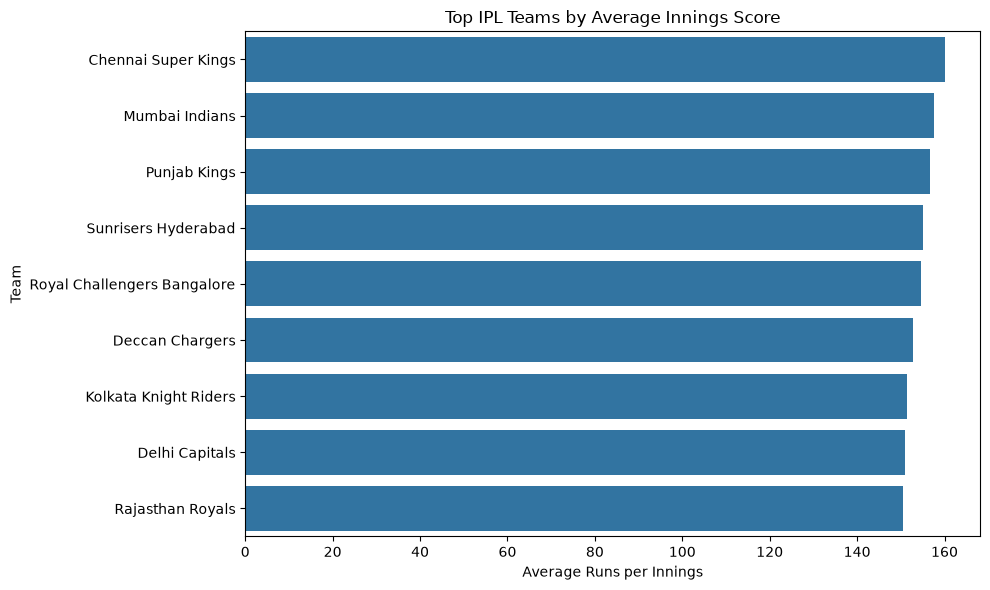

In [56]:
reliable_batting = team_batting[
    team_batting['count'] >= 50
].sort_values('mean', ascending=False)

print(reliable_batting)



reliable_batting_plot = reliable_batting.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=reliable_batting_plot.head(10), x='mean', y='batting_team')

plt.title('Top IPL Teams by Average Innings Score')
plt.xlabel('Average Runs per Innings')
plt.ylabel('Team')
plt.tight_layout()
plt.show()


In [57]:
# Bowling Analysis
bowling_stats = (deliveries.groupby('bowler').agg(runs_conceded = ('total_runs', 'sum'), balls = ('ball', 'count')))

bowling_stats['overs'] = bowling_stats['balls'] / 6

bowling_stats['economy'] = (bowling_stats['runs_conceded'] / bowling_stats['overs']).round(2)

bowling_stats = bowling_stats[bowling_stats['balls'] >= 300].sort_values('economy')

bowling_stats.head(10)

,runs_conceded,balls,overs,economy
bowler,,,,
A Kumble,1089,983,163.833333,6.65
GD McGrath,366,329,54.833333,6.67
DW Steyn,2454,2207,367.833333,6.67
M Muralitharan,1765,1581,263.500000,6.70
R Ashwin,3391,3016,502.666667,6.75
RD Chahar,376,333,55.500000,6.77
SP Narine,2939,2600,433.333333,6.78
RE van der Merwe,515,455,75.833333,6.79
Rashid Khan,1257,1106,184.333333,6.82


Top 10 Player of the Match:
player_of_match
CH Gayle          21
AB de Villiers    20
MS Dhoni          17
DA Warner         17
RG Sharma         17
YK Pathan         16
SR Watson         15
SK Raina          14
G Gambhir         13
MEK Hussey        12
Name: count, dtype: int64


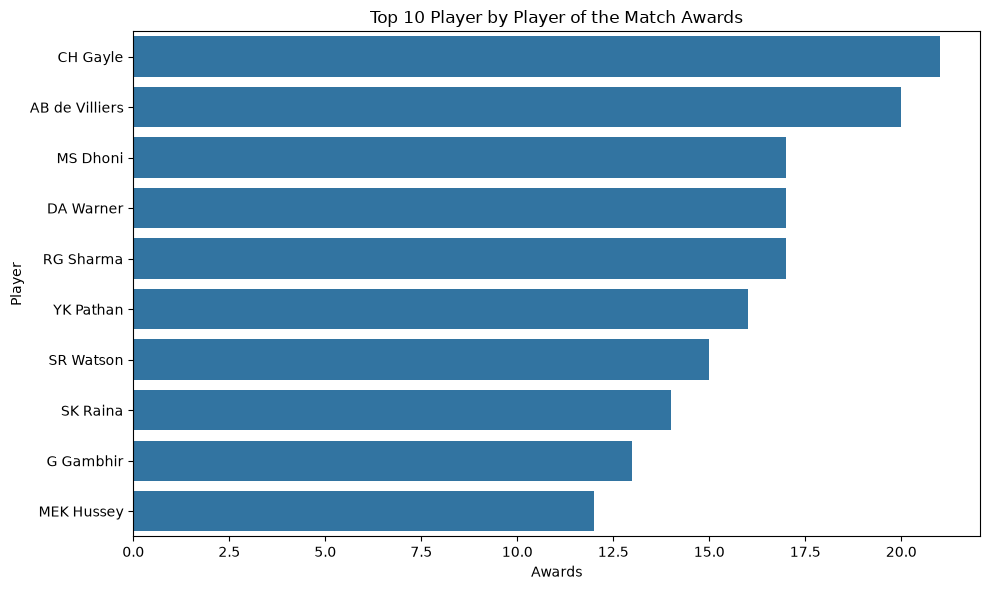

In [58]:
# Player of the Match Analysis

pom = (matches['player_of_match'].value_counts())
print('Top 10 Player of the Match:')
print(pom.head(10))

# Visualization

plt.figure(figsize = (10, 6))
sns.barplot(x = pom.head(10).values, y = pom.head(10).index)
plt.title('Top 10 Player by Player of the Match Awards')
plt.xlabel('Awards')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

In [59]:
# Season-wise matches+ avg runs
season_analysis = matches.groupby('season').agg(matches=('id', 'count'), avg_match_runs=('total_match_runs', 'mean')).round(2)

print(season_analysis)

        matches  avg_match_runs
season                         
2008         58          309.26
2009         57          286.89
2010         60          314.70
2011         73          289.78
2012         74          303.42
2013         76          297.39
2014         60          315.52
2015         59          311.07
2016         60          314.37
2017         59          318.41
2018         60          345.02
2019         60          337.58


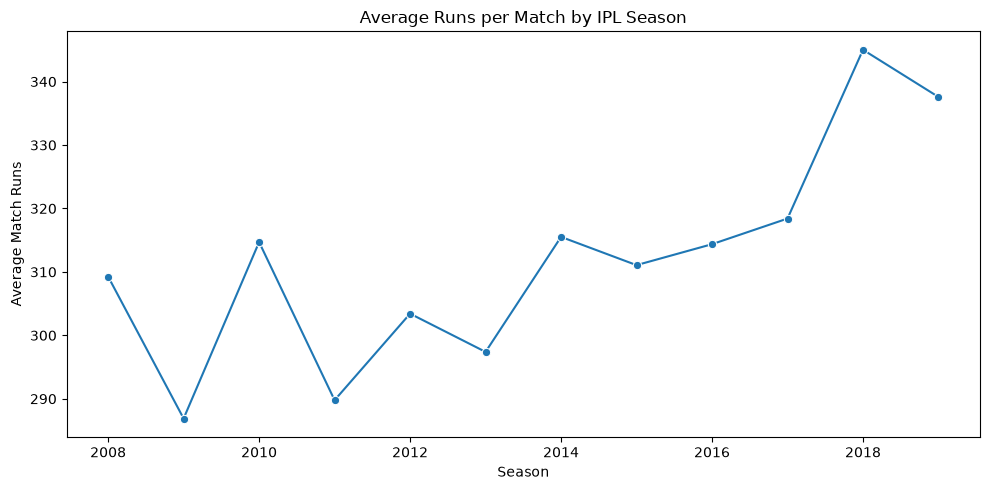

In [60]:
# Avg runs trend

plt.figure(figsize=(10, 5))

sns.lineplot(data=season_analysis, x=season_analysis.index, y='avg_match_runs', marker='o')

plt.title('Average Runs per Match by IPL Season')
plt.xlabel('Season')
plt.ylabel('Average Match Runs')
plt.tight_layout()
plt.show()

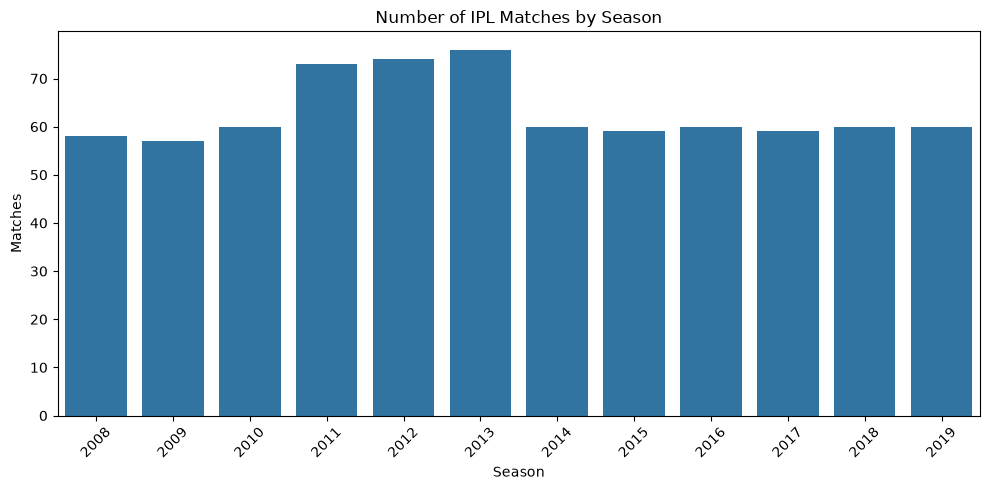

In [61]:
plt.figure(figsize=(10, 5))

sns.barplot(data=season_analysis.reset_index(), x='season', y='matches')

plt.title('Number of IPL Matches by Season')
plt.xlabel('Season')
plt.ylabel('Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [62]:
ml_data = matches[['season', 'team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city', 'dl_applied', 'winner']].copy()

ml_data = ml_data[ml_data['winner'].notna()].copy()
print('Shape:', ml_data.shape)
ml_data.isnull().sum()

Shape: (752, 9)


season           0
team1            0
team2            0
toss_winner      0
toss_decision    0
venue            0
city             7
dl_applied       0
winner           0
dtype: int64

In [63]:
ml_data['city'] = ml_data['city'].fillna('Unknown')

In [64]:
ml_data.isnull().sum()

season           0
team1            0
team2            0
toss_winner      0
toss_decision    0
venue            0
city             0
dl_applied       0
winner           0
dtype: int64

In [65]:
x = ml_data.drop('winner', axis = 1)
y = ml_data['winner']

In [66]:
x.columns.tolist()

['season',
 'team1',
 'team2',
 'toss_winner',
 'toss_decision',
 'venue',
 'city',
 'dl_applied']

In [67]:
y.value_counts()

winner
Mumbai Indians                 109
Chennai Super Kings            100
Kolkata Knight Riders           92
Royal Challengers Bangalore     84
Punjab Kings                    82
Delhi Capitals                  77
Rajasthan Royals                75
Sunrisers Hyderabad             58
Deccan Chargers                 29
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [68]:
train_data = ml_data[ml_data['season'] < 2019].copy()
test_data = ml_data[ml_data['season'] == 2019].copy()

In [69]:
x_train = train_data.drop('winner', axis = 1)
y_train = train_data['winner']

In [70]:
x_test = test_data.drop('winner', axis = 1)
y_test = test_data['winner']

In [71]:
x_train.shape, x_test.shape

((693, 8), (59, 8))

In [72]:
categorical_features = ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city']

numeric_features = ['season', 'dl_applied']

In [73]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers = [('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features),
                   ('num', 'passthrough', numeric_features)]
)

In [74]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [75]:
models = {
    'Logistic Regression': LogisticRegression(max_iter = 1000),
    'Decision Tree': DecisionTreeClassifier(max_depth = 5, random_state = 42),
    'Random Forest' : RandomForestClassifier(n_estimators = 100, max_depth = 8, random_state = 42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)
}

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
trained_models = {}

for name, model in models.items():
    
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])

    # train
    pipeline.fit(x_train, y_train)

    #predict
    y_pred = pipeline.predict(x_test)

    # metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average = 'weighted', zero_division = 0)
    recall = recall_score(y_test, y_pred, average = 'weighted', zero_division = 0)
    f1 = f1_score(y_test, y_pred, average = 'weighted', zero_division = 0)

    results.append([name, accuracy, precision, recall, f1])
    trained_models[name] = pipeline

results_df = pd.DataFrame(results, columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score'])

results_df = results_df.sort_values('Accuracy', ascending = False)

results_df
    

C:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.610169,0.621348,0.610169,0.593678
0,Logistic Regression,0.559322,0.566034,0.559322,0.537114
3,Gradient Boosting,0.525424,0.563156,0.525424,0.484072
1,Decision Tree,0.355932,0.329661,0.355932,0.332182


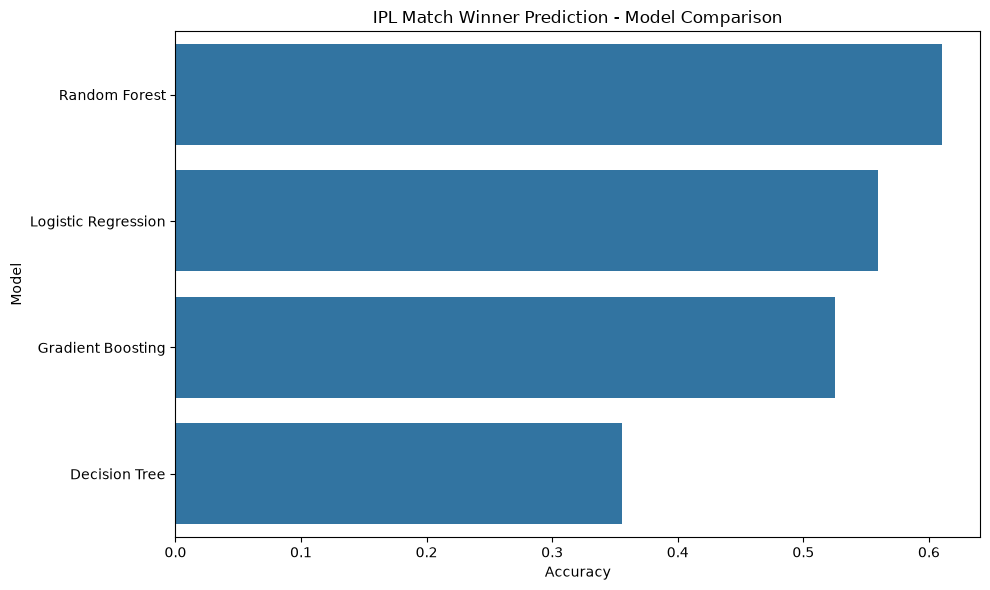

In [77]:
plt.figure(figsize = (10, 6))
sns.barplot(data = results_df, x = 'Accuracy', y = 'Model')

plt.title('IPL Match Winner Prediction - Model Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

In [78]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]

print('Best Model:', best_model_name)
print('Best Accuracy:', round(results_df.iloc[0]['Accuracy'] * 100, 2), '%')

Best Model: Random Forest
Best Accuracy: 61.02 %


In [79]:
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state = 42)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('Model', rf)
])

param_grid = {
    'Model__n_estimators': [50, 100, 150],
    'Model__max_depth' : [5, 8, 10],
    'Model__min_samples_split' : [2, 5]
}

grid_search = GridSearchCV(pipeline, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)

grid_search.fit(x_train, y_train)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'Model__max_depth': 8, 'Model__min_samples_split': 5, 'Model__n_estimators': 150}
0.5714419768532999


In [80]:
y_pred = grid_search.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print('Tuned Random Forest Accuracy:', round(accuracy * 100, 2), '%')

Tuned Random Forest Accuracy: 64.41 %


In [81]:
print("Accuracy :", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred, average='weighted') * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred, average='weighted') * 100, 2), "%")
print("F1 Score :", round(f1_score(y_test, y_pred, average='weighted') * 100, 2), "%")

Accuracy : 64.41 %
Precision: 65.4 %
Recall   : 64.41 %
F1 Score : 62.99 %


In [82]:
new_match = pd.DataFrame({
    'season': [2019],
    'team1': ['Mumbai Indians'],
    'team2': ['Chennai Super Kings'],
    'toss_winner': ['Mumbai Indian'],
    'toss_decision': ['bat'],
    'venue': ['Wankhede Stadium'],
    'city' : ['Mumbai'],
    'dl_applied': [0]
    
        
})

In [83]:
prediction = grid_search.predict(new_match)
prediction[0]

'Mumbai Indians'